# **1. Import Libraries**

In [1]:
import json
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

# **2. Declare Constances**

In [2]:
BASE_DIR = Path.cwd().parents[0]
DATA_DIR = BASE_DIR / "sample_data"
RAW_DATA = DATA_DIR / "raw"

# **3. Load Raw Data**

In [3]:
raw_train_df = pl.read_csv(RAW_DATA / "train.csv")
raw_test_df = pl.read_csv(RAW_DATA / "test.csv")
with open(RAW_DATA / "categories.json", "r", encoding="utf-8") as fin:
    categories = json.load(fin)
    categories = sorted(categories, key=lambda x: x.lower())
    labels = [i for i in range(len(categories))]
    categories_df = pl.DataFrame({
        "label": labels,
        "category": categories
    })

In [4]:
print(raw_train_df.head())
print(f"The number of rows in train data: {len(raw_train_df)}.")

shape: (5, 2)
┌─────────────────────────────────┬───────┐
│ text                            ┆ label │
│ ---                             ┆ ---   │
│ str                             ┆ i64   │
╞═════════════════════════════════╪═══════╡
│ I am still waiting on my card?  ┆ 11    │
│ What can I do if my card still… ┆ 11    │
│ I have been waiting over a wee… ┆ 11    │
│ Can I track my card while it i… ┆ 11    │
│ How do I know if I will get my… ┆ 11    │
└─────────────────────────────────┴───────┘
The number of rows in train data: 10003.


In [5]:
print(raw_test_df.head())
print(f"The number of rows in test data: {len(raw_test_df)}.")

shape: (5, 2)
┌─────────────────────────────────┬───────┐
│ text                            ┆ label │
│ ---                             ┆ ---   │
│ str                             ┆ i64   │
╞═════════════════════════════════╪═══════╡
│ How do I locate my card?        ┆ 11    │
│ I still have not received my n… ┆ 11    │
│ I ordered a card but it has no… ┆ 11    │
│ Is there a way to know when my… ┆ 11    │
│ My card has not arrived yet.    ┆ 11    │
└─────────────────────────────────┴───────┘
The number of rows in test data: 3080.


In [6]:
print(categories_df.head())
print(f"The number of categories in dataset: {len(categories_df)}.")

shape: (5, 2)
┌───────┬─────────────────────────┐
│ label ┆ category                │
│ ---   ┆ ---                     │
│ i64   ┆ str                     │
╞═══════╪═════════════════════════╡
│ 0     ┆ activate_my_card        │
│ 1     ┆ age_limit               │
│ 2     ┆ apple_pay_or_google_pay │
│ 3     ┆ atm_support             │
│ 4     ┆ automatic_top_up        │
└───────┴─────────────────────────┘
The number of categories in dataset: 77.


# **4. Exploratory Data Analysis**

In [7]:
def get_number_label(df):
    return set([row["label"] for row in df.iter_rows(named=True)
                if row["label"] in labels])

In [8]:
train_categories = get_number_label(raw_train_df)
print(f"The number of missing label in train data: {len(categories) - len(train_categories)}.")

The number of missing label in train data: 0.


In [9]:
test_categories = get_number_label(raw_test_df)
print(f"The number of missing label in test data: {len(categories) - len(test_categories)}.")

The number of missing label in test data: 0.


In [10]:
def get_text_length_df(df):
    return df.with_columns(
        pl.Series(
            "text_length", 
            [len(row) for row in df["text"].to_list()]
        )
    )

In [11]:
text_length_train_df = get_text_length_df(raw_train_df)
print(text_length_train_df["text_length"].describe())

shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 10003.0   │
│ null_count ┆ 0.0       │
│ mean       ┆ 59.473758 │
│ std        ┆ 40.867901 │
│ min        ┆ 13.0      │
│ 25%        ┆ 36.0      │
│ 50%        ┆ 47.0      │
│ 75%        ┆ 64.0      │
│ max        ┆ 433.0     │
└────────────┴───────────┘


In [12]:
text_length_test_df = get_text_length_df(raw_test_df)
print(text_length_test_df["text_length"].describe())

shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 3080.0    │
│ null_count ┆ 0.0       │
│ mean       ┆ 54.232468 │
│ std        ┆ 34.658008 │
│ min        ┆ 13.0      │
│ 25%        ┆ 35.0      │
│ 50%        ┆ 45.0      │
│ 75%        ┆ 60.0      │
│ max        ┆ 368.0     │
└────────────┴───────────┘


In [13]:
def plot_text_length_distribution(df):
    plt.figure(figsize=(12, 5))
    
    sns.histplot(df["text_length"], kde=True, bins=100)

    plt.title("Text Length Distribution (Words)", fontsize=14)
    plt.xlabel("Number of words", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.show()

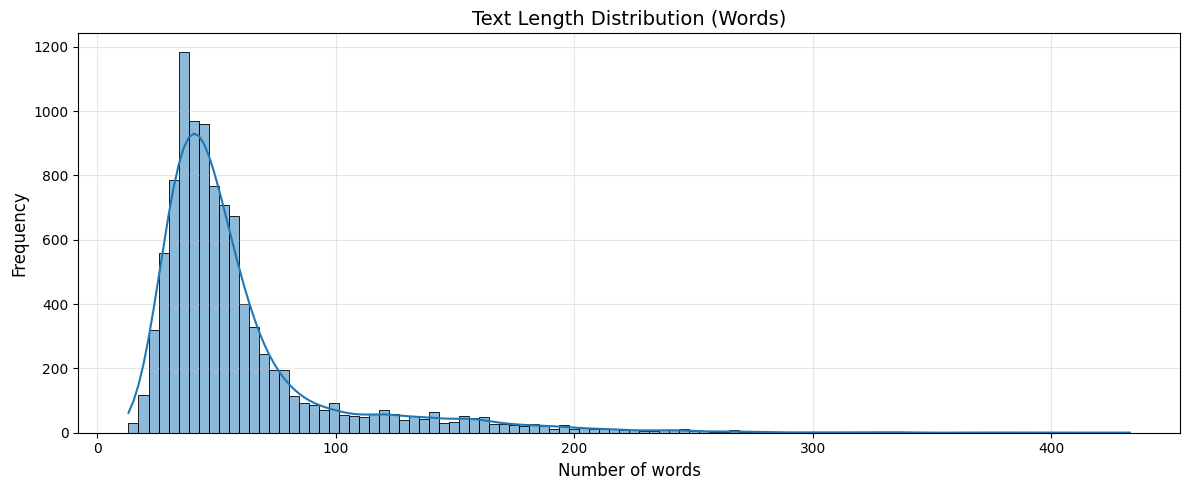

In [14]:
plot_text_length_distribution(text_length_train_df)

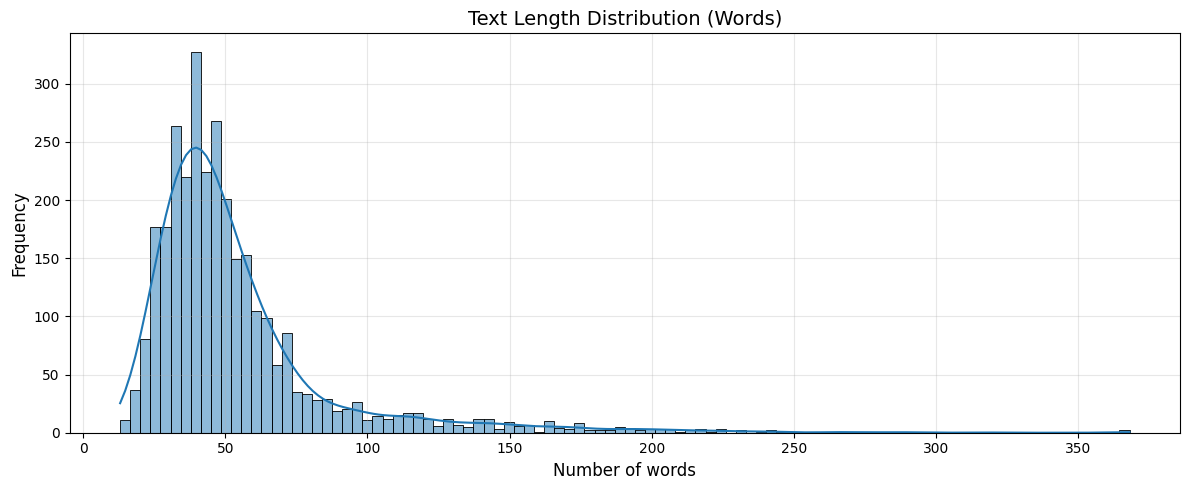

In [15]:
plot_text_length_distribution(text_length_test_df)

The average number of words in both train and test data is around 54 to 59 words.

In [16]:
print(raw_train_df["label"].describe())

shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 10003.0   │
│ null_count ┆ 0.0       │
│ mean       ┆ 37.651704 │
│ std        ┆ 22.391016 │
│ min        ┆ 0.0       │
│ 25%        ┆ 18.0      │
│ 50%        ┆ 37.0      │
│ 75%        ┆ 57.0      │
│ max        ┆ 76.0      │
└────────────┴───────────┘


In [17]:
print(raw_test_df["label"].describe())

shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 3080.0   │
│ null_count ┆ 0.0      │
│ mean       ┆ 38.0     │
│ std        ┆ 22.22972 │
│ min        ┆ 0.0      │
│ 25%        ┆ 19.0     │
│ 50%        ┆ 38.0     │
│ 75%        ┆ 57.0     │
│ max        ┆ 76.0     │
└────────────┴──────────┘


In [18]:
def plot_category_distribution(df):
    plt.figure(figsize=(12, 5))
    
    sns.histplot(data=df, kde=True, x="label", bins=77)

    plt.title("Category Distribution", fontsize=14)
    plt.xlabel("Categories", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.show()

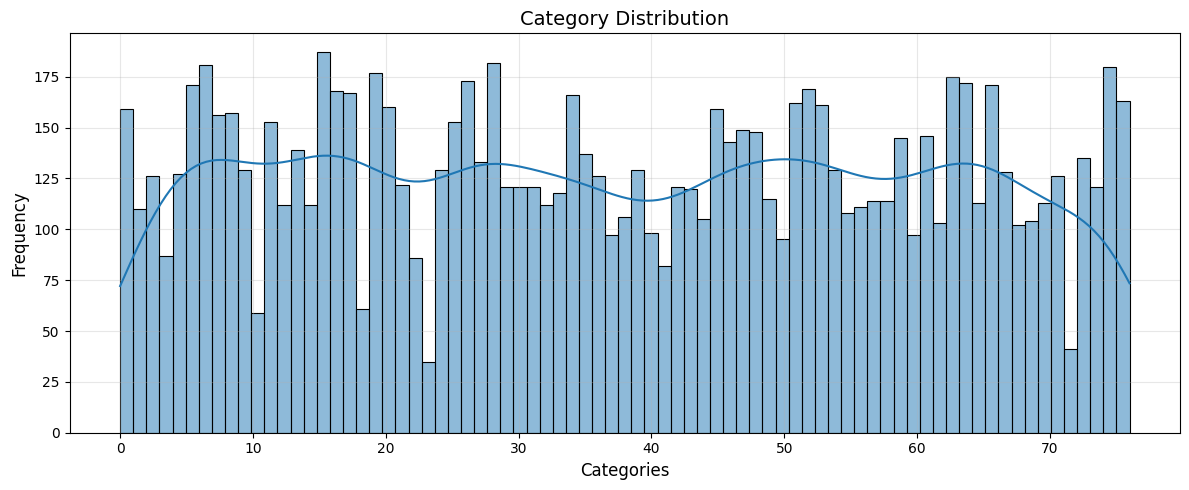

In [19]:
plot_category_distribution(raw_train_df)

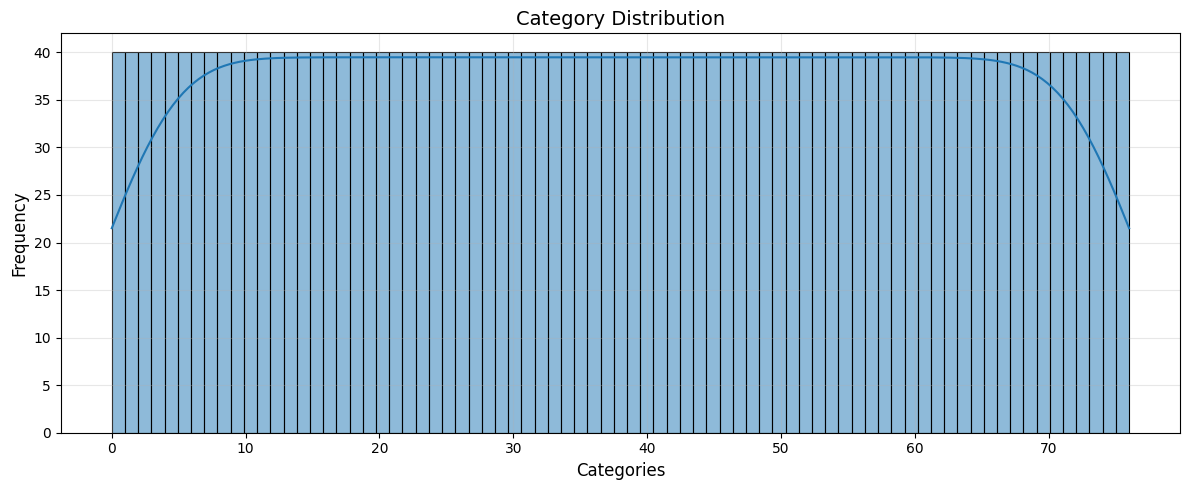

In [20]:
plot_category_distribution(raw_test_df)

In general, the categories distribution in test data is equal, while not equally distributed in train data.